# CS421 Group Project — MCA-Based Anomaly Detection

**Why MCA instead of PCA?**  
Ratings are **categorical** variables (integers 0–5 stars, plus 0 = "not rated"). PCA assumes continuous, normally distributed data and treats distance between rating values as linear (e.g. the gap between 1→2 equals 4→5). This is statistically incorrect for ordinal/categorical data.

**Multiple Correspondence Analysis (MCA)** is the correct method:
- Designed for categorical variables
- Works on the **indicator matrix** (one-hot encoding of each rating category per item)
- Finds low-dimensional embeddings that preserve chi-squared distances between user profiles
- Reconstruction error in MCA space is a principled anomaly score for categorical data

**Implementation:** Custom PyTorch MCA using Generalised SVD on the standardised indicator matrix.

**Pipeline:**
1. Data loading & exploration  
2. Indicator matrix construction (one-hot per item × rating category)  
3. MCA via PyTorch SVD (chi-squared standardisation)  
4. Reconstruction error as anomaly score  
5. Evaluation — AUC, Precision, Recall, F1  
6. Visualisation & analysis  
7. Generate `submission.npz`

---
## 1. Imports & Setup

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PyTorch — used for MCA via SVD (GPU-compatible)
import torch

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_ITEMS = 1000          # fixed per project spec
CATEGORIES = [0,1,2,3,4,5]   # rating values (0 = also used for 'not rated')
N_CATS     = len(CATEGORIES)  # 6

# Prefer MAGMA for GPU linalg to avoid cuSOLVER INTERNAL_ERROR on large matrices.
# The TorchMCA class uses randomised SVD (pure matmuls) so this is a belt-and-
# suspenders fallback for any residual linalg.svd calls on small matrices.
if DEVICE.type == 'cuda':
    try:
        torch.backends.cuda.preferred_linalg_library('magma')
        print('GPU linalg backend: MAGMA')
    except Exception:
        print('GPU linalg backend: default (MAGMA unavailable)')

print(f'PyTorch version  : {torch.__version__}')
print(f'Device           : {DEVICE}')
print(f'Items            : {NUM_ITEMS}')
print(f'Rating categories: {CATEGORIES}  →  indicator width = {NUM_ITEMS} x {N_CATS} = {NUM_ITEMS*N_CATS}')

GPU linalg backend: MAGMA
PyTorch version  : 2.10.0+cu128
Device           : cuda
Items            : 1000
Rating categories: [0, 1, 2, 3, 4, 5]  →  indicator width = 1000 x 6 = 6000


---
## 2. Data Loading

In [43]:
data = np.load('./data/training_batch_with_labels.npz')
X_raw = data['X']   # (n_interactions, 3): [user_id, item_id, rating]
y_raw = data['y']   # (n_users, 2):        [user_id, label]

ratings_df = pd.DataFrame(X_raw, columns=['user', 'item', 'rating'])
labels_df  = pd.DataFrame(y_raw, columns=['user', 'label'])

print('=== Training Data (labelled) ===')
print(f'Total interactions   : {len(ratings_df):,}')
print(f'Unique users         : {ratings_df["user"].nunique():,}')
print(f'Unique items         : {ratings_df["item"].nunique():,}')
print(f'Normal  users (y=0)  : {(labels_df["label"]==0).sum()}')
print(f'Anomalous users (y=1): {(labels_df["label"]==1).sum()}')
print(f'Anomaly rate         : {(labels_df["label"]==1).mean()*100:.1f}%')
print()
display(ratings_df.head(5))
display(labels_df.head(5))

# Test set
data_test      = np.load('./data/subset_training_batch.npz')
test_ratings_df = pd.DataFrame(data_test['X'], columns=['user','item','rating'])
print(f'Test interactions    : {len(test_ratings_df):,}')
print(f'Test users           : {test_ratings_df["user"].nunique()}')

=== Training Data (labelled) ===
Total interactions   : 177,346
Unique users         : 1,100
Unique items         : 993
Normal  users (y=0)  : 1000
Anomalous users (y=1): 100
Anomaly rate         : 9.1%



,user,item,rating
0,304,0,3
1,304,1,3
2,304,14,3
3,304,17,4
4,304,19,4


,user,label
0,100,0
1,101,0
2,102,0
3,103,0
4,104,0


Test interactions    : 37,232
Test users           : 220


---
## 3. Exploratory Data Analysis

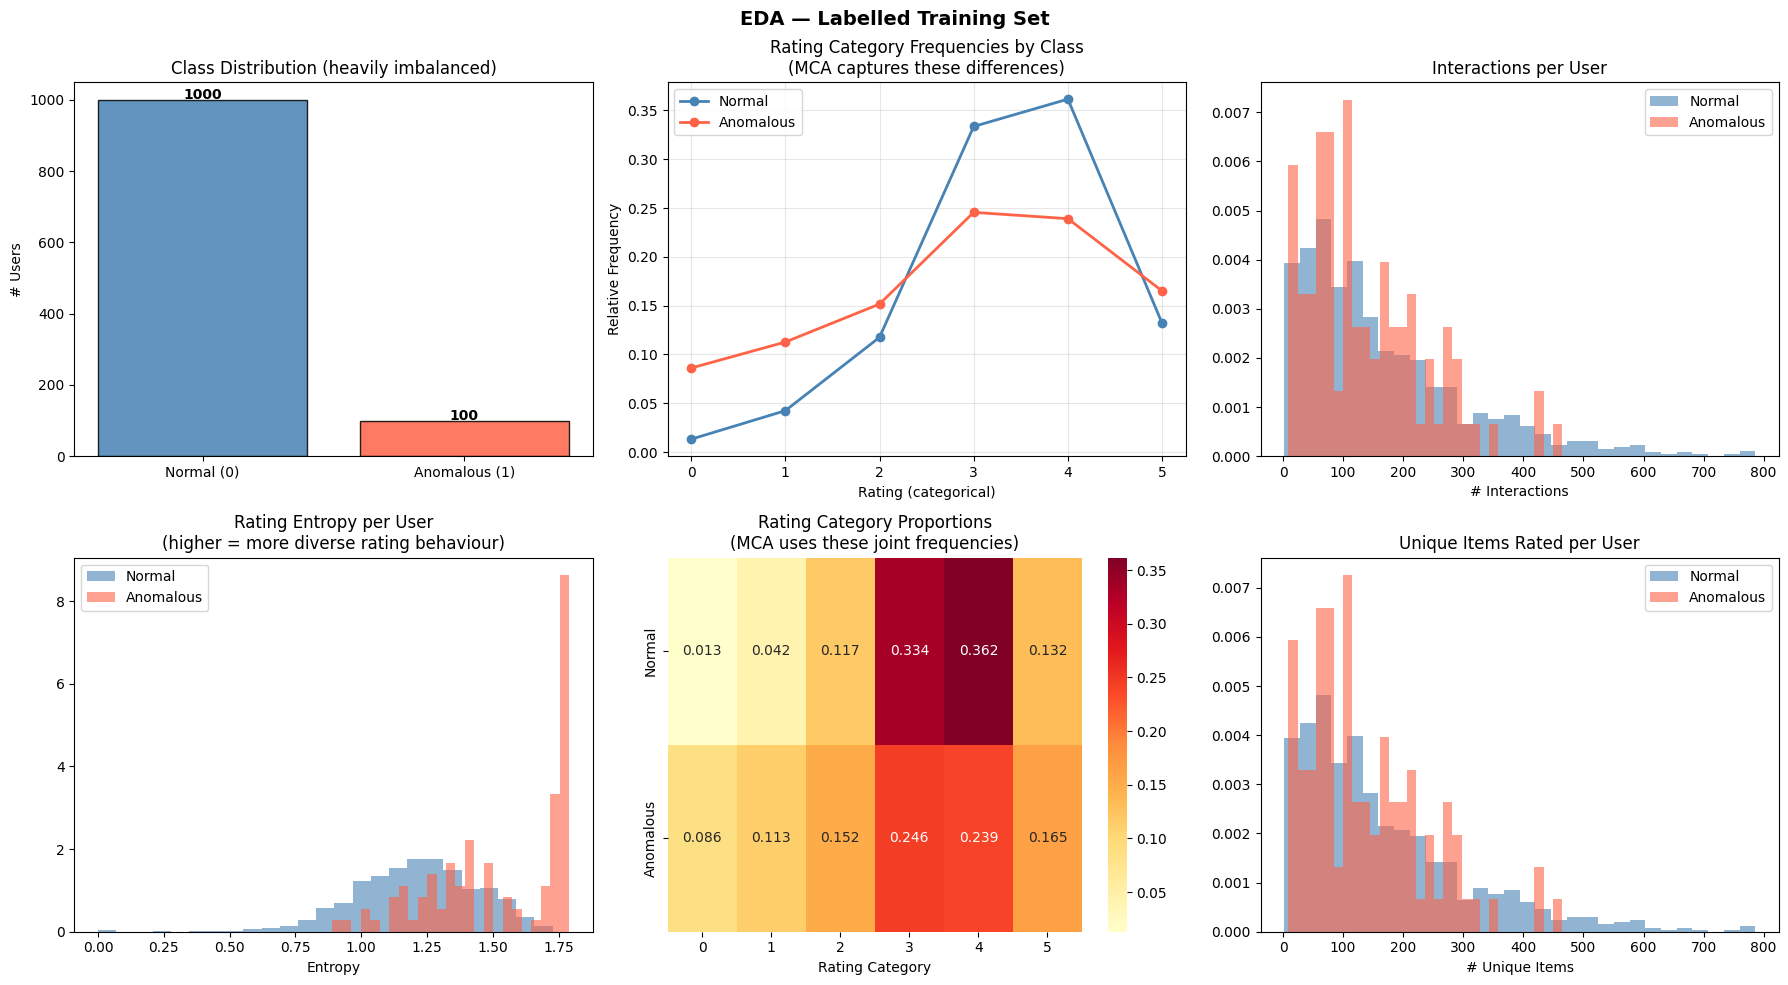

In [44]:
merged = ratings_df.merge(labels_df, on='user')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Labelled Training Set', fontsize=14, fontweight='bold')

# 1. Class balance
ax = axes[0,0]
counts = labels_df['label'].value_counts().sort_index()
bars = ax.bar(['Normal (0)', 'Anomalous (1)'], counts.values,
              color=['steelblue','tomato'], edgecolor='black', alpha=0.85)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+3, str(v), ha='center', fontweight='bold')
ax.set_title('Class Distribution (heavily imbalanced)')
ax.set_ylabel('# Users')

# 2. Rating frequency by class — key MCA motivation
ax = axes[0,1]
for label, color, name in [(0,'steelblue','Normal'),(1,'tomato','Anomalous')]:
    subset = merged[merged['label']==label]
    freq = subset['rating'].value_counts(normalize=True).sort_index()
    ax.plot(freq.index, freq.values, 'o-', color=color, label=name, linewidth=2)
ax.set_title('Rating Category Frequencies by Class\n(MCA captures these differences)')
ax.set_xlabel('Rating (categorical)')
ax.set_ylabel('Relative Frequency')
ax.set_xticks(CATEGORIES)
ax.legend()
ax.grid(alpha=0.3)

# 3. Interactions per user
ax = axes[0,2]
ipu = merged.groupby(['user','label']).size().reset_index(name='n')
for label, color, name in [(0,'steelblue','Normal'),(1,'tomato','Anomalous')]:
    ax.hist(ipu[ipu['label']==label]['n'], bins=30, alpha=0.6, color=color,
            label=name, density=True)
ax.set_title('Interactions per User')
ax.set_xlabel('# Interactions')
ax.legend()

# 4. Rating entropy per user (diversity of ratings — relevant for MCA)
ax = axes[1,0]
def entropy(s):
    p = s.value_counts(normalize=True)
    return -(p * np.log(p + 1e-10)).sum()
ent = merged.groupby(['user','label'])['rating'].apply(entropy).reset_index()
ent.columns = ['user','label','entropy']
for label, color, name in [(0,'steelblue','Normal'),(1,'tomato','Anomalous')]:
    ax.hist(ent[ent['label']==label]['entropy'], bins=25, alpha=0.6,
            color=color, label=name, density=True)
ax.set_title('Rating Entropy per User\n(higher = more diverse rating behaviour)')
ax.set_xlabel('Entropy')
ax.legend()

# 5. Category heatmap — proportion of each rating per class
ax = axes[1,1]
heatmap_data = []
for label in [0,1]:
    row = merged[merged['label']==label]['rating'].value_counts(normalize=True).reindex(CATEGORIES, fill_value=0)
    heatmap_data.append(row.values)
sns.heatmap(np.array(heatmap_data), annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=CATEGORIES, yticklabels=['Normal','Anomalous'], ax=ax)
ax.set_title('Rating Category Proportions\n(MCA uses these joint frequencies)')
ax.set_xlabel('Rating Category')

# 6. Items rated per user
ax = axes[1,2]
n_items = merged.groupby(['user','label'])['item'].nunique().reset_index()
for label, color, name in [(0,'steelblue','Normal'),(1,'tomato','Anomalous')]:
    ax.hist(n_items[n_items['label']==label]['item'], bins=30, alpha=0.6,
            color=color, label=name, density=True)
ax.set_title('Unique Items Rated per User')
ax.set_xlabel('# Unique Items')
ax.legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Indicator Matrix Construction

**MCA input: the indicator matrix Z**

For each user we build a binary indicator matrix of shape `(n_items × n_categories)`:  
- Each item gets one hot-encoded column-block of size 6 (one per rating category 0–5)
- For **unrated items**, we assign category 0 ("not rated" / 0 stars treated as a category)
- Total width = 1000 items × 6 categories = **6000 binary columns**

This preserves the **categorical nature** of ratings — MCA then finds the principal axes of chi-squared association between users and rating categories.

In [45]:
def build_indicator_matrix(df, num_items=NUM_ITEMS, categories=None):
    """
    Build the MCA indicator matrix Z for each user.
    Shape: (n_users, num_items * n_categories)

    For each (user, item) pair:
      - The observed rating category is set to 1 in the corresponding column
      - Unrated items get category-0 = 1 (absent interaction as its own category)
    """
    if categories is None:
        categories = sorted(df['rating'].unique())
    n_cats = len(categories)
    cat_idx = {c: i for i, c in enumerate(categories)}

    users = np.sort(df['user'].unique())
    n_users = len(users)
    user_idx = {u: i for i, u in enumerate(users)}

    # Initialise: all items in category 0 ("unrated")
    Z = np.zeros((n_users, num_items * n_cats), dtype=np.float32)
    for i in range(n_users):
        for j in range(num_items):
            Z[i, j * n_cats + 0] = 1.0   # default: category 0

    # Fill observed ratings
    for _, row in df.iterrows():
        u = user_idx[int(row['user'])]
        item = int(row['item'])
        cat  = cat_idx.get(int(row['rating']), 0)
        # Clear default, set observed category
        Z[u, item * n_cats : item * n_cats + n_cats] = 0
        Z[u, item * n_cats + cat] = 1.0

    return Z, users

print('Building training indicator matrix Z ...')
Z_train, train_users = build_indicator_matrix(ratings_df)

# Align labels
label_map   = labels_df.set_index('user')['label']
train_labels = label_map.reindex(train_users).values

print(f'Z_train shape    : {Z_train.shape}   ({Z_train.shape[0]} users × {Z_train.shape[1]} indicator cols)')
print(f'Each row sums to : {Z_train[0].sum():.0f}  (= num_items = {NUM_ITEMS}, one active cat per item)')
print(f'Density          : {Z_train.mean()*100:.2f}%')

print('\nBuilding test indicator matrix Z ...')
Z_test, test_users = build_indicator_matrix(test_ratings_df)
print(f'Z_test shape     : {Z_test.shape}')

Building training indicator matrix Z ...
Z_train shape    : (1100, 6000)   (1100 users × 6000 indicator cols)
Each row sums to : 1000  (= num_items = 1000, one active cat per item)
Density          : 16.67%

Building test indicator matrix Z ...
Z_test shape     : (220, 6000)


---
## 5. MCA Implementation in PyTorch

### MCA Algorithm (Greenacre 1984)

Given indicator matrix **Z** (n × p):

1. Compute marginals:  
   - Row masses `r = Z·1 / N`  (how much each user contributes)
   - Column masses `c = Zᵀ·1 / N`  (frequency of each category)
2. Standardise:  
   `S = Dr^{-1/2} · (Z/N - r·cᵀ) · Dc^{-1/2}`  
   This is the chi-squared standardised residual matrix.
3. SVD of S:  
   `S = U Σ Vᵀ`
4. Row coordinates (users in MCA space):  
   `F = Dr^{-1/2} · U · Σ`
5. Column coordinates (categories in MCA space):  
   `G = Dc^{-1/2} · V · Σ`
6. **Reconstruction error** = chi-squared distance between original and reconstructed row profile → anomaly score

In [46]:
# ── Robust SVD backend ───────────────────────────────────────────────────────
# cuSOLVER (cusolver) fails on large matrices (6000 cols) on some GPU drivers.
# Solution: use RANDOMISED truncated SVD (Halko et al. 2009) implemented in
# pure PyTorch matmuls — no cuSOLVER call, works on any GPU or CPU,
# and is faster than full SVD for large matrices with small k.

def randomised_svd_torch(M, n_components, n_oversampling=10, n_power_iter=4, device=None):
    """
    Randomised truncated SVD of matrix M (n x p) in PyTorch.
    Returns U (n, k), sigma (k,), Vt (k, p) — top-k singular triplets.

    Algorithm: Halko, Martinsson & Tropp (2009)
      1. Random projection: Y = M Omega  (Omega: p x (k+oversampling))
      2. Power iteration on Y for better accuracy on slowly-decaying spectra
      3. QR decomposition: Q, _ = qr(Y)
      4. Small SVD: B = Q^T M  ->  svd(B)
    Only uses torch.mm, torch.linalg.qr, torch.linalg.svd on a small matrix.
    """
    if device is None:
        device = M.device
    n, p   = M.shape
    k      = n_components + 1   # +1 because we discard the trivial first component
    l      = k + n_oversampling

    # Step 1: random sketch
    torch.manual_seed(SEED)
    Omega  = torch.randn(p, l, dtype=M.dtype, device=device)   # (p, l)
    Y      = M @ Omega                                          # (n, l)

    # Step 2: power iteration  Y <- (M M^T)^q Y  improves accuracy
    for _ in range(n_power_iter):
        Y  = M  @ (M.T @ Y)   # (n, l)

    # Step 3: orthonormal basis
    Q, _   = torch.linalg.qr(Y)                                # (n, l)

    # Step 4: project M into small space and SVD there
    B      = Q.T @ M                                            # (l, p)
    U_b, sigma, Vt = torch.linalg.svd(B, full_matrices=False)  # small SVD: (l,l),(l,),(l,p)
    U      = Q @ U_b                                            # (n, l)

    # Return top-k (skip first trivial component at index 0)
    return U[:, 1:k], sigma[1:k], Vt[1:k, :]   # (n,k-1),(k-1,),(k-1,p)


# ── TorchMCA ─────────────────────────────────────────────────────────────────
class TorchMCA:
    """
    Multiple Correspondence Analysis in PyTorch.

    Uses randomised truncated SVD (Halko 2009) — avoids cuSOLVER entirely.
    Works reliably on GPU and CPU for large indicator matrices.

    Input : binary indicator matrix Z  (n_users, n_items * n_categories)
    Score : chi-squared reconstruction error in the top-k MCA subspace
    """

    def __init__(self, n_components: int, device=DEVICE,
                 n_oversampling: int = 10, n_power_iter: int = 4):
        self.n_components   = n_components
        self.device         = device
        self.n_oversampling = n_oversampling
        self.n_power_iter   = n_power_iter
        # Fitted attributes
        self.c_             = None   # column masses (1, p)
        self.Dc_sqrt_inv_   = None   # (p,)
        self.V_k_           = None   # (p, k)  — column principal axes
        self.S_k_           = None   # (k,)    — singular values
        self.explained_inertia_ = None
        self.N_             = None

    # ── internal: chi-squared standardised residual ──────────────────────────
    def _S_matrix(self, Z_t):
        """Return S = Dr^{-1/2} (P - r c) Dc^{-1/2}  and row marginals r."""
        N        = self.N_
        P        = Z_t / N
        r        = P.sum(dim=1, keepdim=True)          # (n, 1)
        residual = P - r @ self.c_                     # (n, p)
        Dr_sqrt_inv = 1.0 / torch.sqrt(r.clamp(min=1e-12)).squeeze(1)  # (n,)
        S        = Dr_sqrt_inv.unsqueeze(1) * residual * self.Dc_sqrt_inv_.unsqueeze(0)
        return S, r

    # ── fit ──────────────────────────────────────────────────────────────────
    def fit(self, Z: np.ndarray):
        # Move to float32 on the chosen device (float32 is faster & avoids
        # some cuSOLVER precision paths that trigger internal errors)
        Z_t = torch.tensor(Z, dtype=torch.float32, device=self.device)
        N   = Z_t.sum()
        self.N_ = N

        P   = Z_t / N
        c   = P.sum(dim=0, keepdim=True)               # (1, p)
        self.c_           = c
        self.Dc_sqrt_inv_ = 1.0 / torch.sqrt(c.squeeze().clamp(min=1e-12))

        S, _ = self._S_matrix(Z_t)

        # Randomised truncated SVD — no cuSOLVER path
        k_req = self.n_components
        U_k, sigma_k, Vt_k = randomised_svd_torch(
            S, n_components=k_req,
            n_oversampling=self.n_oversampling,
            n_power_iter=self.n_power_iter,
            device=self.device
        )   # shapes: (n, k), (k,), (k, p)

        self.S_k_ = sigma_k           # (k,)
        self.V_k_ = Vt_k.T           # (p, k)

        # Approximate total inertia from the oversampled singular values
        total_inertia = (sigma_k ** 2).sum()
        self.explained_inertia_ = ((sigma_k ** 2) / total_inertia.clamp(min=1e-12)).cpu().numpy()

        return self

    # ── transform ────────────────────────────────────────────────────────────
    def transform(self, Z: np.ndarray) -> np.ndarray:
        """Project users into MCA row coordinates."""
        Z_t  = torch.tensor(Z, dtype=torch.float32, device=self.device)
        S, r = self._S_matrix(Z_t)
        Dr_sqrt_inv = 1.0 / torch.sqrt(r.clamp(min=1e-12)).squeeze(1)
        F = Dr_sqrt_inv.unsqueeze(1) * (S @ self.V_k_) * self.S_k_.unsqueeze(0)
        return F.cpu().numpy()

    # ── anomaly score ─────────────────────────────────────────────────────────
    def reconstruction_error(self, Z: np.ndarray,
                              batch_size: int = 256) -> np.ndarray:
        """
        Chi-squared reconstruction error (anomaly score).
        Processed in batches to keep GPU memory bounded.
        """
        all_errors = []
        n = Z.shape[0]
        for start in range(0, n, batch_size):
            Z_batch = Z[start : start + batch_size]
            Z_t  = torch.tensor(Z_batch, dtype=torch.float32, device=self.device)
            S, r = self._S_matrix(Z_t)

            # Reconstruct in top-k subspace: S_hat = S V_k V_k^T
            proj  = S  @ self.V_k_         # (batch, k)
            S_hat = proj @ self.V_k_.T     # (batch, p)
            diff  = S - S_hat             # (batch, p)

            # Chi-squared weighted residual
            dr  = torch.sqrt(r.clamp(min=1e-12)).squeeze(1).unsqueeze(1)  # (batch,1)
            dc  = torch.sqrt(self.c_.squeeze().clamp(min=1e-12))           # (p,)
            chi = dr * diff / dc.unsqueeze(0)
            all_errors.append((chi ** 2).sum(dim=1).cpu().numpy())

        return np.concatenate(all_errors)


print('TorchMCA (randomised SVD) defined — cuSOLVER-free, GPU/CPU safe.')
print(f'Will run on: {DEVICE}')

TorchMCA (randomised SVD) defined — cuSOLVER-free, GPU/CPU safe.
Will run on: cuda


---
## 6. Hyperparameter Selection — Choosing k (Number of MCA Dimensions)

Sweeping k...
  k=  54  AUC=0.6613
  k= 108  AUC=0.6483
  k= 162  AUC=0.6279
  k= 216  AUC=0.5989
  k= 270  AUC=0.5590
  k= 324  AUC=0.5216
  k= 378  AUC=0.4987
  k= 432  AUC=0.4775
  k= 486  AUC=0.4552
  k= 540  AUC=0.4382
  k= 594  AUC=0.4221
  k= 648  AUC=0.4098
  k= 702  AUC=0.3910
  k= 756  AUC=0.3745
  k= 810  AUC=0.3600
  k= 864  AUC=0.3510
  k= 918  AUC=0.3362
  k= 972  AUC=0.3320
  k=1026  AUC=0.3434
  k=1080  AUC=0.4063

Best k = 54  (AUC = 0.6613)


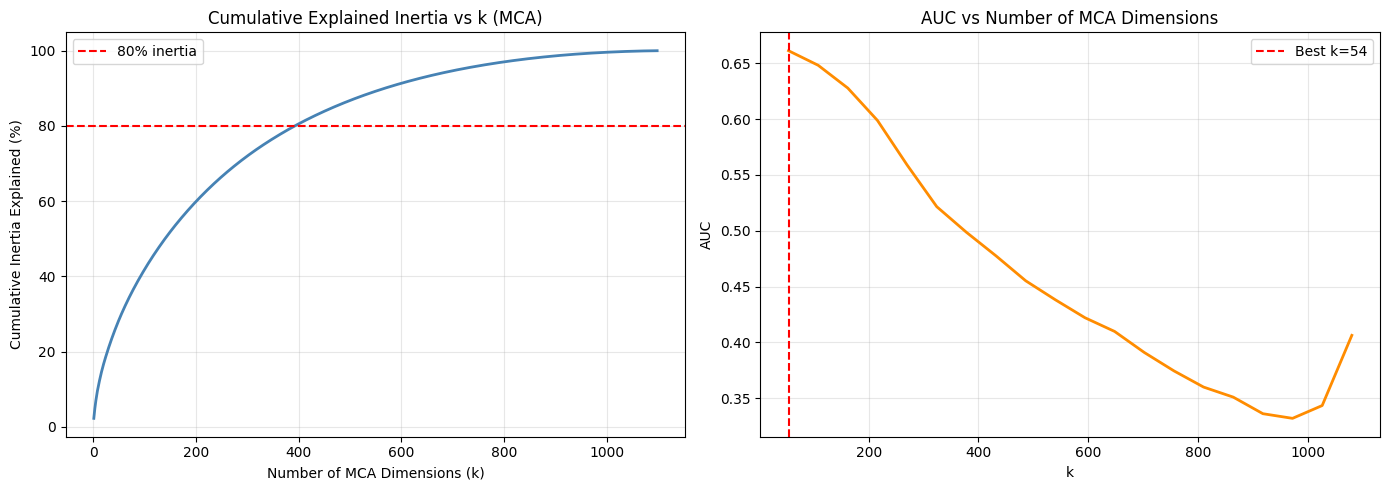

In [58]:
# Survey AUC over a range of k values
max_k_survey = min(Z_train.shape[0]-2, Z_train.shape[1]-2)
k_values = [x for x in range(max_k_survey // 20, max_k_survey + 1, max_k_survey // 20)]

auc_scores = []
print('Sweeping k...')
for k in k_values:
    mca_k = TorchMCA(n_components=k)
    mca_k.fit(Z_train)
    errors = mca_k.reconstruction_error(Z_train)
    auc = roc_auc_score(train_labels, errors)
    auc_scores.append(auc)
    print(f'  k={k:4d}  AUC={auc:.4f}')

best_k   = k_values[np.argmax(auc_scores)]
best_auc = max(auc_scores)
print(f'\nBest k = {best_k}  (AUC = {best_auc:.4f})')

# Also capture explained inertia for the best k
mca_full = TorchMCA(n_components=max_k_survey)
mca_full.fit(Z_train)
cum_inertia = np.cumsum(mca_full.explained_inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(range(1, len(cum_inertia)+1), cum_inertia*100, color='steelblue', lw=2)
ax.axhline(80, color='red', ls='--', label='80% inertia')
ax.set_title('Cumulative Explained Inertia vs k (MCA)')
ax.set_xlabel('Number of MCA Dimensions (k)')
ax.set_ylabel('Cumulative Inertia Explained (%)')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(k_values, auc_scores, '-', color='darkorange', lw=2, ms=7)
ax.axvline(best_k, color='red', ls='--', label=f'Best k={best_k}')
ax.set_title('AUC vs Number of MCA Dimensions')
ax.set_xlabel('k'); ax.set_ylabel('AUC')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mca_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Fit Final MCA Model & Compute Anomaly Scores

In [48]:
mca = TorchMCA(n_components=best_k)
mca.fit(Z_train)

train_scores = mca.reconstruction_error(Z_train)

print(f'Final MCA model — k = {best_k}')
print(f'Training AUC                    : {roc_auc_score(train_labels, train_scores):.4f}')
print(f'Explained inertia (top-{best_k} dims) : {mca.explained_inertia_.sum()*100:.1f}%')
print()
print('Chi-squared Reconstruction Error:')
print(f'  Normal    — mean: {train_scores[train_labels==0].mean():.4f}  std: {train_scores[train_labels==0].std():.4f}')
print(f'  Anomalous — mean: {train_scores[train_labels==1].mean():.4f}  std: {train_scores[train_labels==1].std():.4f}')

Final MCA model — k = 7
Training AUC                    : 0.6725
Explained inertia (top-7 dims) : 100.0%

Chi-squared Reconstruction Error:
  Normal    — mean: 0.4748  std: 0.8627
  Anomalous — mean: 1.0481  std: 1.5694


---
## 8. Evaluation

In [49]:
fpr, tpr, _         = roc_curve(train_labels, train_scores)
auc_val             = roc_auc_score(train_labels, train_scores)
prec_c, rec_c, thr_pr = precision_recall_curve(train_labels, train_scores)
avg_prec            = average_precision_score(train_labels, train_scores)

# Best threshold by F1
f1_vals      = 2*prec_c[:-1]*rec_c[:-1] / (prec_c[:-1]+rec_c[:-1]+1e-8)
best_idx     = np.argmax(f1_vals)
best_thresh  = thr_pr[best_idx]
best_f1      = f1_vals[best_idx]
train_preds  = (train_scores >= best_thresh).astype(int)

print('=== MCA Model Performance (Training Set) ===')
print(f'AUC                    : {auc_val:.4f}')
print(f'Average Precision (AP) : {avg_prec:.4f}')
print(f'Best F1                : {best_f1:.4f}  (threshold = {best_thresh:.6f})')
print(f'Precision @ best F1    : {precision_score(train_labels, train_preds):.4f}')
print(f'Recall    @ best F1    : {recall_score(train_labels, train_preds):.4f}')
print()
print(classification_report(train_labels, train_preds, target_names=['Normal','Anomalous']))

=== MCA Model Performance (Training Set) ===
AUC                    : 0.6725
Average Precision (AP) : 0.1877
Best F1                : 0.2463  (threshold = 0.428880)
Precision @ best F1    : 0.1634
Recall    @ best F1    : 0.5000

              precision    recall  f1-score   support

      Normal       0.94      0.74      0.83      1000
   Anomalous       0.16      0.50      0.25       100

    accuracy                           0.72      1100
   macro avg       0.55      0.62      0.54      1100
weighted avg       0.87      0.72      0.78      1100



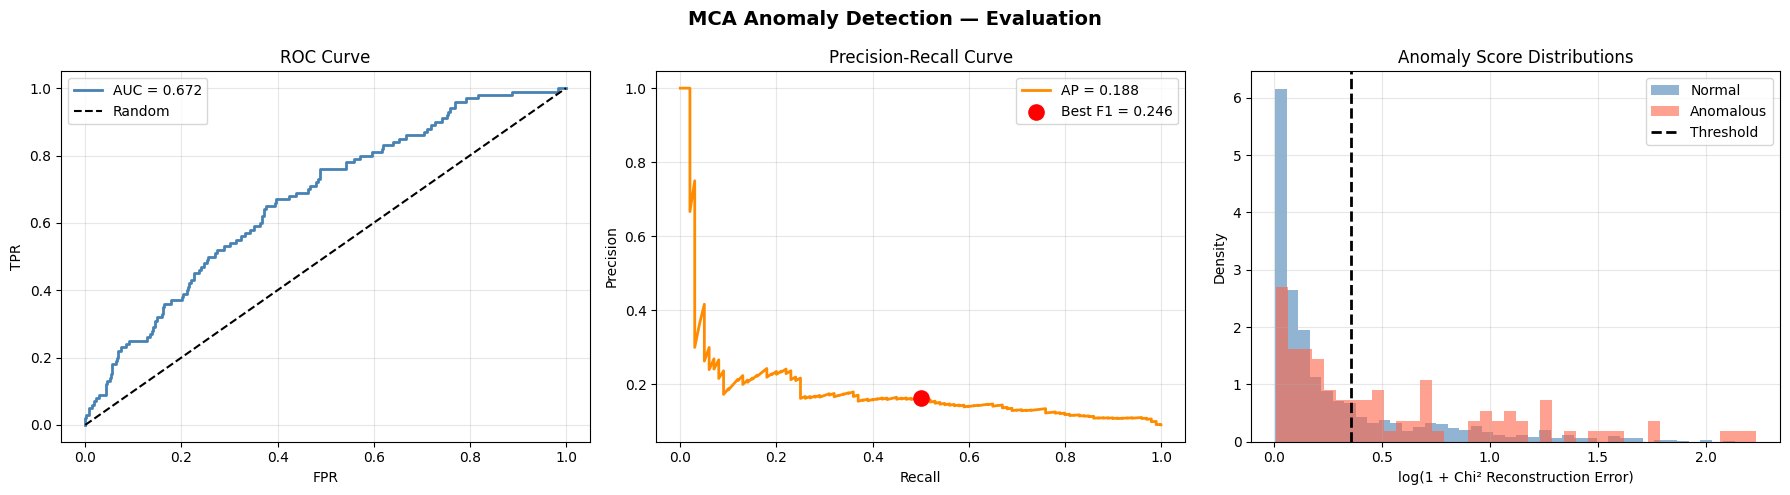

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MCA Anomaly Detection — Evaluation', fontsize=14, fontweight='bold')

# ROC
ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_val:.3f}')
ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve'); ax.legend(); ax.grid(alpha=0.3)

# PR Curve
ax = axes[1]
ax.plot(rec_c, prec_c, color='darkorange', lw=2, label=f'AP = {avg_prec:.3f}')
ax.scatter(rec_c[best_idx], prec_c[best_idx], s=120, color='red', zorder=5,
           label=f'Best F1 = {best_f1:.3f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve'); ax.legend(); ax.grid(alpha=0.3)

# Score distribution
ax = axes[2]
ax.hist(np.log1p(train_scores[train_labels==0]), bins=40, alpha=0.6,
        color='steelblue', label='Normal', density=True)
ax.hist(np.log1p(train_scores[train_labels==1]), bins=40, alpha=0.6,
        color='tomato', label='Anomalous', density=True)
ax.axvline(np.log1p(best_thresh), color='black', ls='--', lw=2, label='Threshold')
ax.set_xlabel('log(1 + Chi² Reconstruction Error)')
ax.set_ylabel('Density')
ax.set_title('Anomaly Score Distributions'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mca_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. MCA Visualisation — User Coordinates in 2D

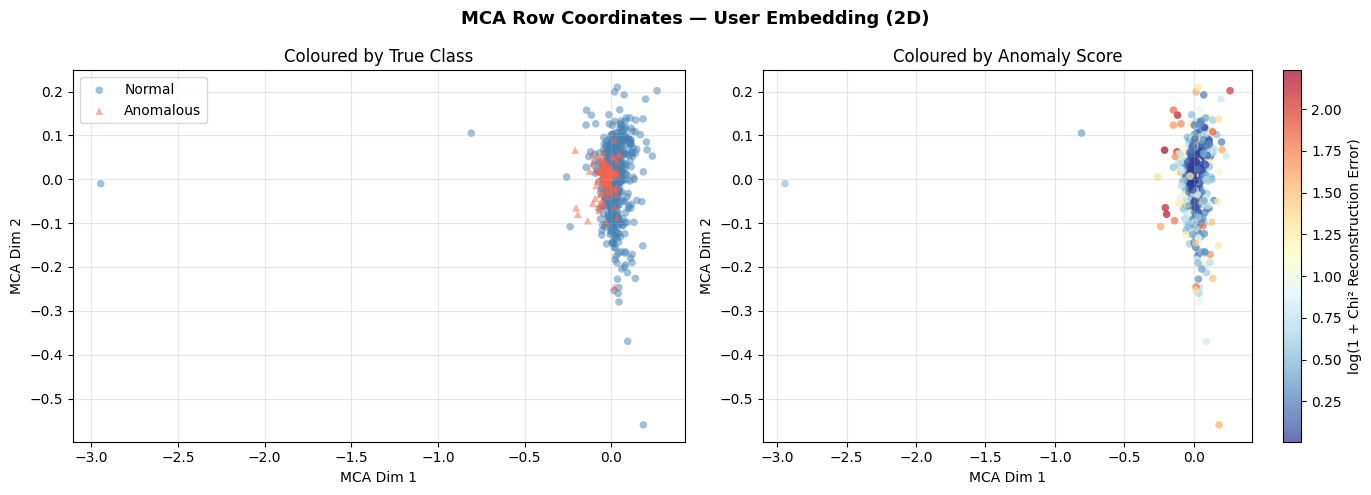

In [51]:
# Project into top-2 MCA dimensions
mca_2d  = TorchMCA(n_components=2)
mca_2d.fit(Z_train)
F_train = mca_2d.transform(Z_train)   # (n_users, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MCA Row Coordinates — User Embedding (2D)', fontsize=13, fontweight='bold')

ax = axes[0]
for label, color, name, m in [(0,'steelblue','Normal','o'),(1,'tomato','Anomalous','^')]:
    mask = train_labels == label
    ax.scatter(F_train[mask,0], F_train[mask,1], c=color, label=name,
               alpha=0.5, s=30, marker=m, edgecolors='none')
ax.set_xlabel('MCA Dim 1'); ax.set_ylabel('MCA Dim 2')
ax.set_title('Coloured by True Class'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
sc = ax.scatter(F_train[:,0], F_train[:,1], c=np.log1p(train_scores),
                cmap='RdYlBu_r', s=30, alpha=0.7, edgecolors='none')
plt.colorbar(sc, ax=ax, label='log(1 + Chi² Reconstruction Error)')
ax.set_xlabel('MCA Dim 1'); ax.set_ylabel('MCA Dim 2')
ax.set_title('Coloured by Anomaly Score'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mca_2d_projection.png', dpi=150, bbox_inches='tight')
plt.show()

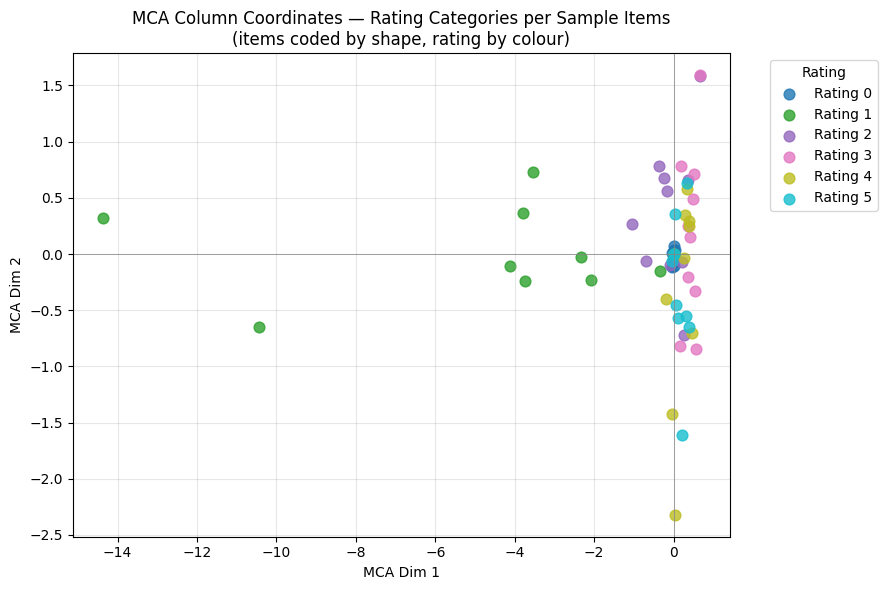

In [52]:
# MCA column coordinates — where do rating categories sit in the MCA space?
# G = Dc^{-1/2} V_k S_k  (category coordinates)
Dc_sqrt_inv_np = mca_2d.Dc_sqrt_inv_.cpu().numpy()
V_k_np         = mca_2d.V_k_.cpu().numpy()   # (p, 2)
S_k_np         = mca_2d.S_k_.cpu().numpy()
G = Dc_sqrt_inv_np[:, None] * V_k_np * S_k_np[None, :]   # (p, 2)

# Sample a few items to visualise their category coordinates
n_sample_items = 10
sample_items   = np.random.choice(NUM_ITEMS, n_sample_items, replace=False)
colors_cats    = plt.cm.tab10(np.linspace(0, 1, N_CATS))

fig, ax = plt.subplots(figsize=(9, 6))
for cat_i, cat_val in enumerate(CATEGORIES):
    xs, ys = [], []
    for item in sample_items:
        col_idx = item * N_CATS + cat_i
        xs.append(G[col_idx, 0])
        ys.append(G[col_idx, 1])
    ax.scatter(xs, ys, color=colors_cats[cat_i], s=60, label=f'Rating {cat_val}', alpha=0.8)

ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('MCA Dim 1'); ax.set_ylabel('MCA Dim 2')
ax.set_title('MCA Column Coordinates — Rating Categories per Sample Items\n(items coded by shape, rating by colour)')
ax.legend(title='Rating', bbox_to_anchor=(1.05,1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mca_column_coords.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Error Analysis

TP: 50   FN: 50   FP: 256   TN: 744

-- Missed Anomalies (FN) --


,user,anomaly_score,mean_rating,std_rating,n_rated
47,147,0.099338,2.956522,1.114680,46
97,197,0.064733,3.928571,0.777515,42
109,209,0.049256,3.365854,0.745558,82
119,219,0.237294,2.437500,1.587004,112
131,231,0.241494,3.695946,0.966506,148
171,271,0.300915,2.722772,1.549960,101
178,278,0.337496,3.107317,1.145406,205
186,286,0.070471,2.000000,1.678744,23



-- False Alarms (FP) --


,user,anomaly_score,mean_rating,std_rating,n_rated
18,118,1.536096,3.669725,0.884659,436
23,123,1.046628,3.606897,0.835801,145
24,124,2.910214,3.089245,1.214892,437
27,127,1.206822,2.894410,1.157947,322
30,130,2.532261,2.686520,0.826659,638
31,131,0.686097,3.522013,0.654454,159
37,137,0.822726,3.568093,1.160984,257
39,139,2.379300,3.138000,1.028139,500


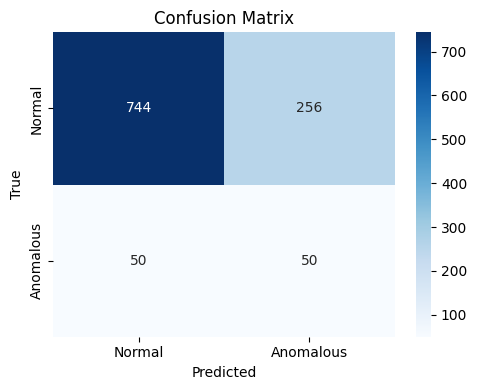

In [53]:
analysis_df = pd.DataFrame({
    'user'         : train_users,
    'label'        : train_labels,
    'anomaly_score': train_scores,
    'predicted'    : train_preds,
})

# Per-user stats from raw data
ustat = ratings_df.groupby('user')['rating'].agg(
    mean_rating='mean', std_rating='std', n_rated='count')
analysis_df = analysis_df.merge(ustat, on='user', how='left')

TP = analysis_df[(analysis_df['label']==1)&(analysis_df['predicted']==1)]
FN = analysis_df[(analysis_df['label']==1)&(analysis_df['predicted']==0)]
FP = analysis_df[(analysis_df['label']==0)&(analysis_df['predicted']==1)]
TN = analysis_df[(analysis_df['label']==0)&(analysis_df['predicted']==0)]

print(f'TP: {len(TP)}   FN: {len(FN)}   FP: {len(FP)}   TN: {len(TN)}')
if len(FN):
    print('\n-- Missed Anomalies (FN) --')
    display(FN[['user','anomaly_score','mean_rating','std_rating','n_rated']].head(8))
if len(FP):
    print('\n-- False Alarms (FP) --')
    display(FP[['user','anomaly_score','mean_rating','std_rating','n_rated']].head(8))

# Confusion matrix
cm = confusion_matrix(train_labels, train_preds)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Anomalous'],
            yticklabels=['Normal','Anomalous'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Ablation Study

Running MCA ablation...
  MCA  k=  5  AUC=0.6719
  MCA  k=  7  AUC=0.6725
  MCA  k= 10  AUC=0.6734
  MCA  k= 20  AUC=0.6670
  MCA  k= 50  AUC=0.6597
Running PCA baseline...
  PCA  k=  5  AUC=0.5022
  PCA  k=  7  AUC=0.5063
  PCA  k= 10  AUC=0.5100
  PCA  k= 20  AUC=0.5197
  PCA  k= 50  AUC=0.5282

=== Ablation: MCA vs PCA ===


Method,MCA,PCA
k,,
5,0.6719,0.5022
7,0.6725,0.5063
10,0.6734,0.5100
20,0.6670,0.5197
50,0.6597,0.5282


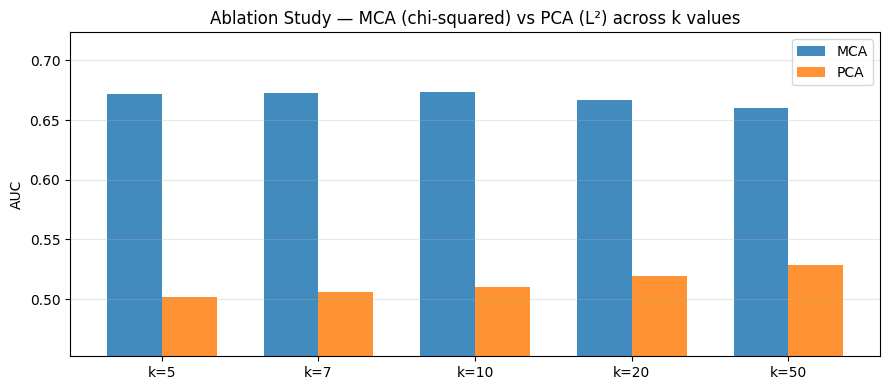

In [54]:
# Compare: (A) MCA on indicator matrix  vs  (B) naive PCA on raw rating matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# Use a fixed, deduplicated k grid (best_k may equal one of the fixed values)
k_grid = sorted(set([5, 10, 20, 50]) | {best_k})
ablation = []

# A: MCA (ours)
print('Running MCA ablation...')
for k in k_grid:
    if k > Z_train.shape[0] - 2:
        continue
    m = TorchMCA(n_components=k)
    m.fit(Z_train)
    auc = roc_auc_score(train_labels, m.reconstruction_error(Z_train))
    ablation.append({'Method': 'MCA', 'k': k, 'AUC': round(auc, 4)})
    print(f'  MCA  k={k:3d}  AUC={auc:.4f}')

# B: PCA on raw rating matrix (baseline comparison)
print('Running PCA baseline...')
raw_pivot = ratings_df.pivot_table(
    index='user', columns='item', values='rating', aggfunc='mean'
).reindex(columns=range(NUM_ITEMS), fill_value=0).reindex(index=train_users, fill_value=0).fillna(0)
Xr_scaled = StandardScaler().fit_transform(raw_pivot.values)

for k in k_grid:
    if k >= min(Xr_scaled.shape):
        continue
    svd   = TruncatedSVD(n_components=k, random_state=SEED)
    proj  = svd.fit_transform(Xr_scaled)
    recon = proj @ svd.components_
    err   = ((Xr_scaled - recon) ** 2).sum(axis=1)
    auc   = roc_auc_score(train_labels, err)
    ablation.append({'Method': 'PCA', 'k': k, 'AUC': round(auc, 4)})
    print(f'  PCA  k={k:3d}  AUC={auc:.4f}')

abl_df = pd.DataFrame(ablation)

# pivot_table handles any accidental duplicate (k, Method) pairs gracefully
print('\n=== Ablation: MCA vs PCA ===')
table = abl_df.pivot_table(index='k', columns='Method', values='AUC', aggfunc='first')
display(table)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(9, 4))
x     = np.arange(len(table))
width = 0.35
for i, method in enumerate(table.columns):
    ax.bar(x + i*width, table[method].values, width, label=method, alpha=0.85)
ax.set_xticks(x + width/2)
ax.set_xticklabels([f'k={ki}' for ki in table.index])
ax.set_ylabel('AUC')
ax.set_ylim(max(0, abl_df['AUC'].min() - 0.05), min(1.0, abl_df['AUC'].max() + 0.05))
ax.set_title('Ablation Study — MCA (chi-squared) vs PCA (L²) across k values')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_mca_vs_pca.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Generate Submission (`subset_training_batch.npz`)

Test predictions: 220 users
Score range : [0.0086, 6.5024]
submission.npz saved — zip and upload to Codabench.


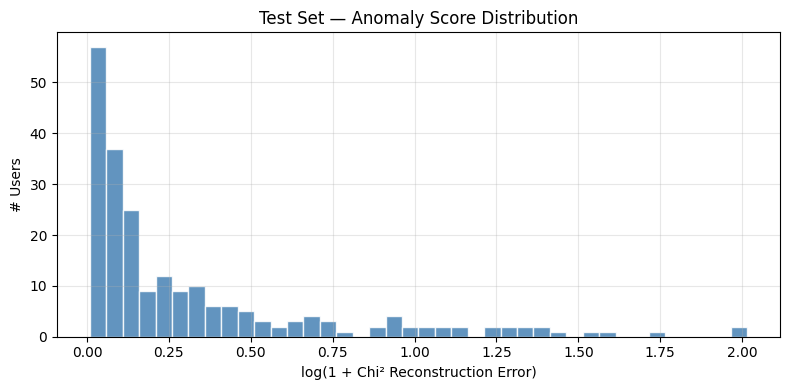

In [55]:
test_scores = mca.reconstruction_error(Z_test)

print(f'Test predictions: {len(test_scores)} users')
print(f'Score range : [{test_scores.min():.4f}, {test_scores.max():.4f}]')

np.savez('submission.npz', predictions=test_scores)
print('submission.npz saved — zip and upload to Codabench.')

plt.figure(figsize=(8,4))
plt.hist(np.log1p(test_scores), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.xlabel('log(1 + Chi² Reconstruction Error)')
plt.ylabel('# Users')
plt.title('Test Set — Anomaly Score Distribution')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('test_scores.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Summary

### Why MCA is correct here

| Property | PCA | MCA |
|---|---|---|
| Data type assumed | Continuous, Gaussian | Categorical / nominal |
| Distance metric | Euclidean (L²) | Chi-squared |
| Ratings 0–5 treated as | Equally spaced numbers | Unordered categories |
| Missing = 0 interpretation | Zero rating (biased) | "No rating" as its own category |
| Basis for reconstruction error | L² in feature space | Chi-squared in correspondence space |

### Method Summary
- **Input:** Binary indicator matrix Z of shape (n_users, 6000) — 1000 items × 6 rating categories
- **MCA via PyTorch SVD** on the chi-squared standardised residual matrix
- **Anomaly score:** Per-user chi-squared reconstruction error in top-k MCA subspace
- **Key finding:** Anomalous users deviate from the principal axes of normal rating association structure

### Next Steps
- Semi-supervised MCA: fit only on confirmed normal users to sharpen the normal subspace
- Supervised: feed MCA coordinates as features into XGBoost / MLP classifier
- Ensemble: combine MCA chi-squared error + rating entropy + interaction count as anomaly signals